# 🚧 Concrete Compressive Strength Prediction

### Import Libraries

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
pip install optuna

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Style
sns.set_style('whitegrid')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

import shap
import optuna

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [11]:
df = pd.read_csv('/content/drive/MyDrive/DATA/concrete.csv')

In [12]:
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
superplastic,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
coarseagg,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
fineagg,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


In [15]:
# Duplicates rows
duplicate_rows = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicate_rows}")

Number of duplicated rows: 25


In [16]:
# Drop duplicated rows
df = df.drop_duplicates()

rows, columns = df.shape

print(f"Number of rows: {rows},", f"Number of columns: {columns}")

Number of rows: 1005, Number of columns: 9


### Exploratory Data Analysis

#### Target Variable Analysis

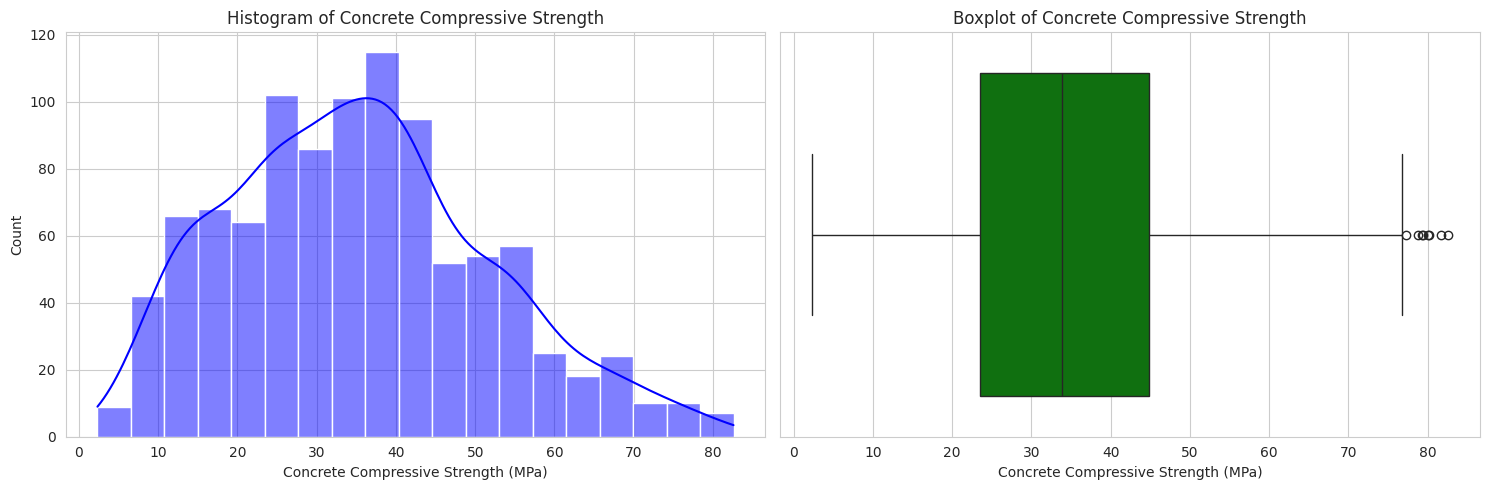

  Skewness: 0.40
  Kurtosis: -0.31


In [17]:
# Histogram and Boxplot of Concrete Compressive Strength
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Histogram
sns.histplot(data = df, x = "strength", ax= axes[0], kde= True, color= "blue")
axes[0].set_title("Histogram of Concrete Compressive Strength")
axes[0].set_xlabel('Concrete Compressive Strength (MPa)')
axes[0].set_ylabel('Count')

# BoxPlot
sns.boxplot(data = df, x = "strength", ax= axes[1], color= "green")
axes[1].set_title('Boxplot of Concrete Compressive Strength')
axes[1].set_xlabel('Concrete Compressive Strength (MPa)')

plt.tight_layout()
plt.show()

print(f"  Skewness: {df['strength'].skew():.2f}")
print(f"  Kurtosis: {df['strength'].kurt():.2f}")

- The compressive strength distribution is approximately normal, with a slight positive skew (0.40) and near-normal kurtosis (-0.31). Strength values range from about 2 MPa to 82 MPa, representing both low- and high-strength concrete mixes. Although a few high-strength outliers were observed, they were retained because they likely reflect valid concrete mixtures rather than data errors.

#### Features analysis

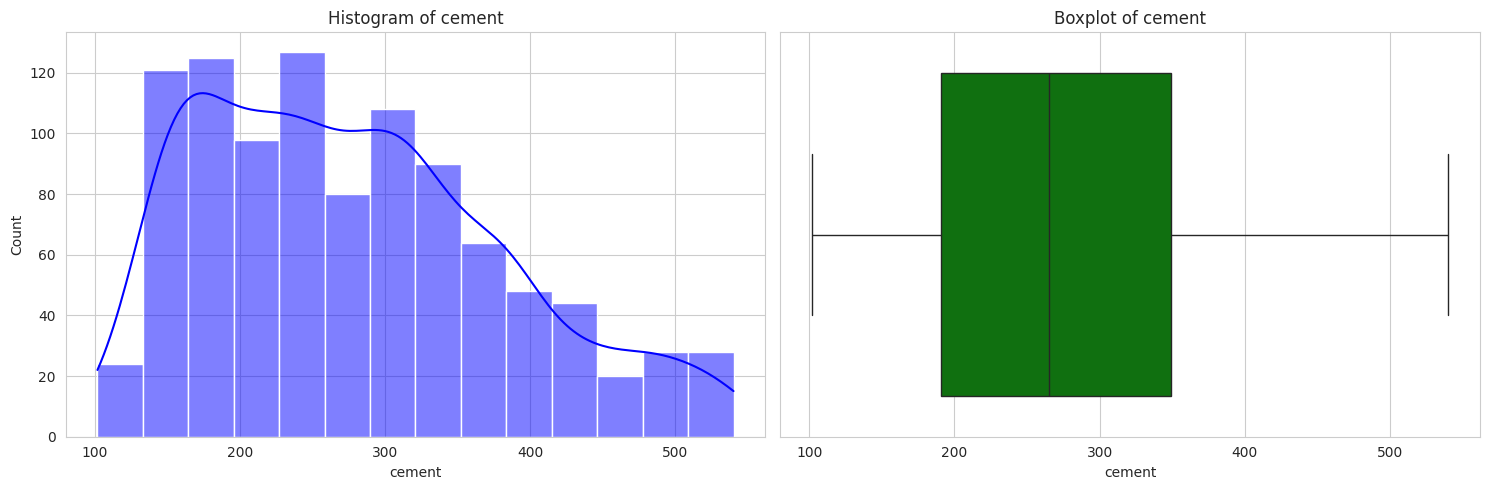

  Skewness: 0.56
  Kurtosis: -0.43


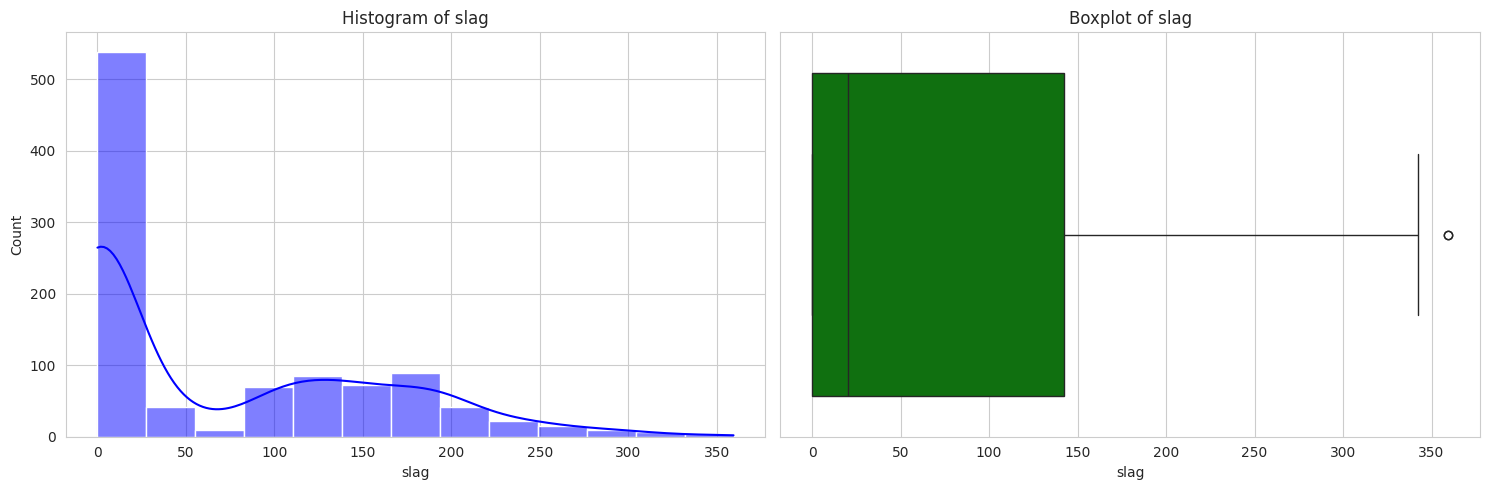

  Skewness: 0.86
  Kurtosis: -0.41


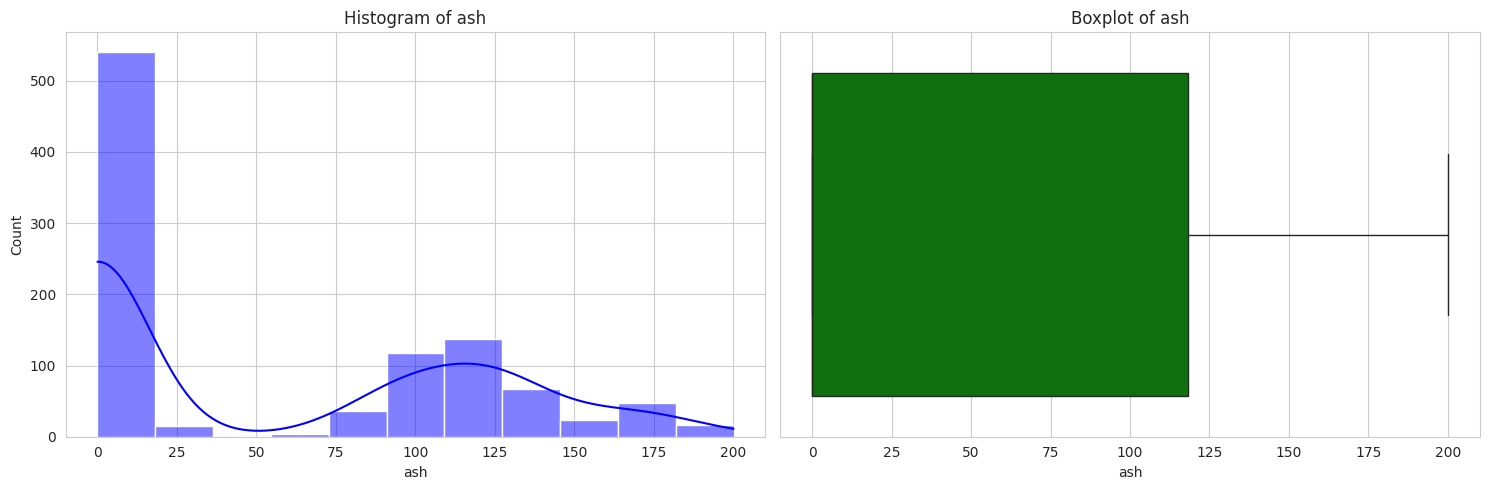

  Skewness: 0.50
  Kurtosis: -1.37


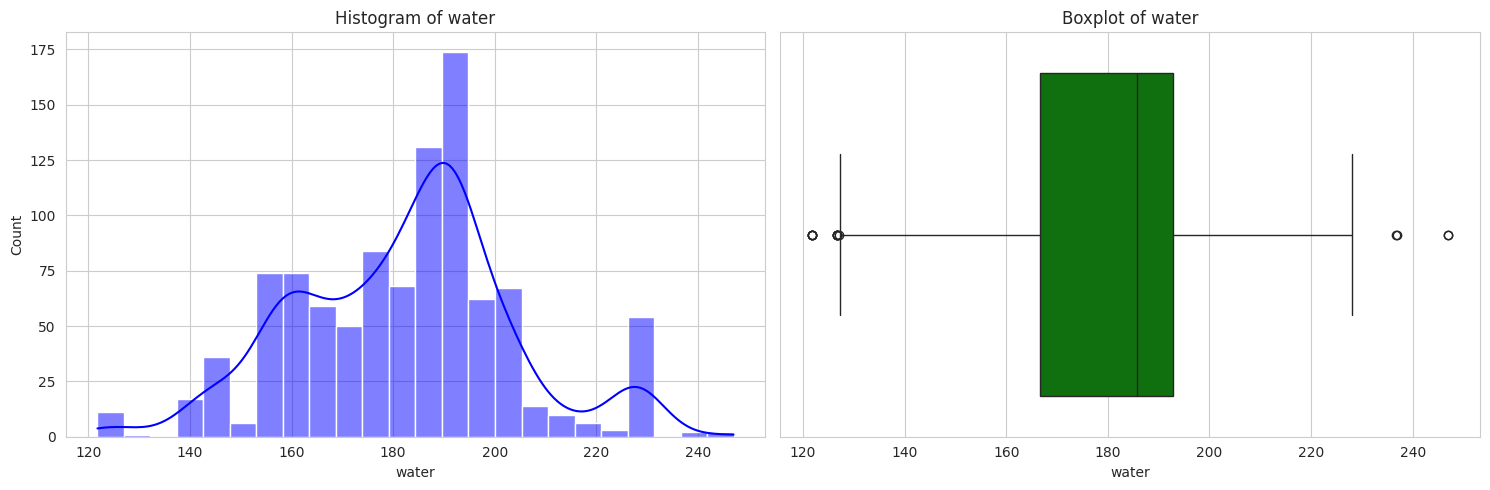

  Skewness: 0.03
  Kurtosis: 0.17


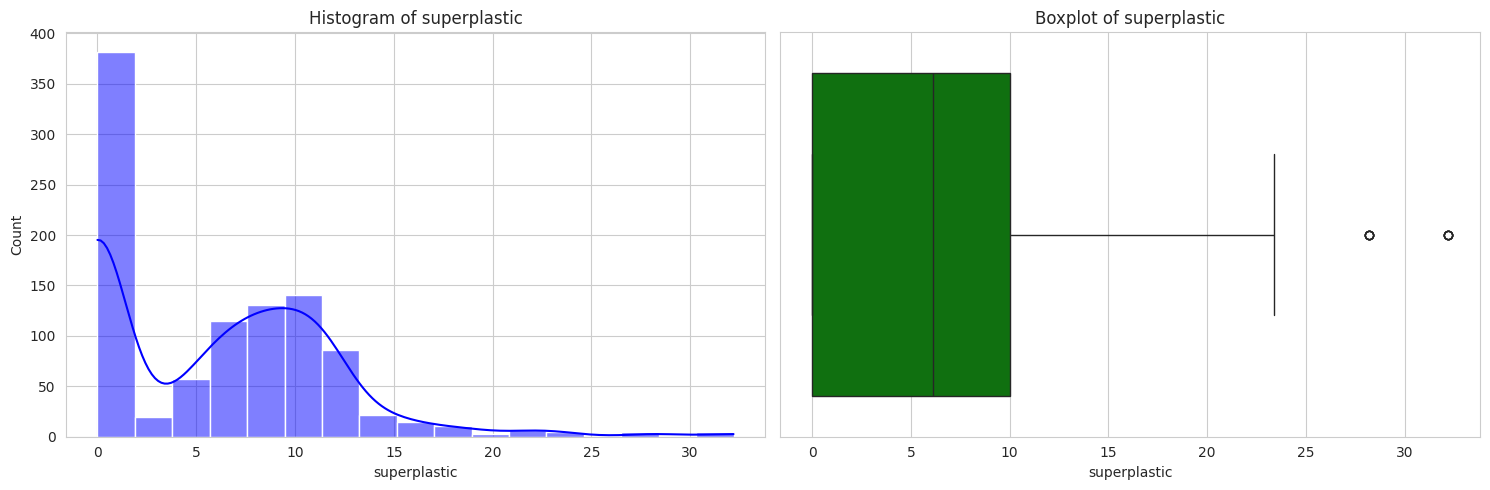

  Skewness: 0.98
  Kurtosis: 1.70


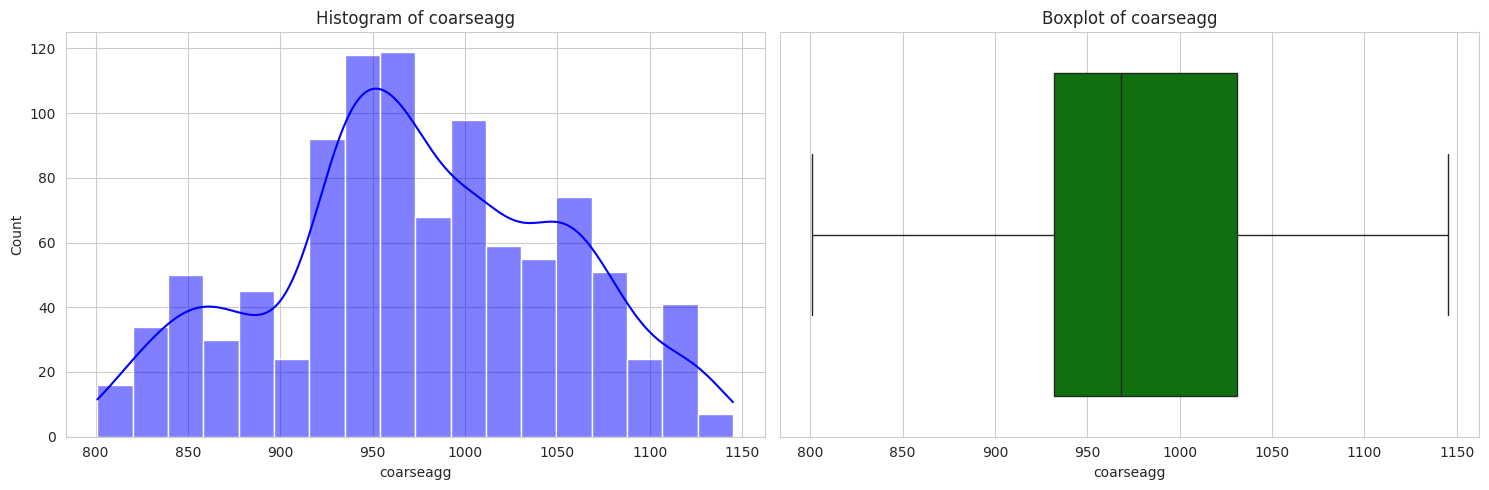

  Skewness: -0.07
  Kurtosis: -0.58


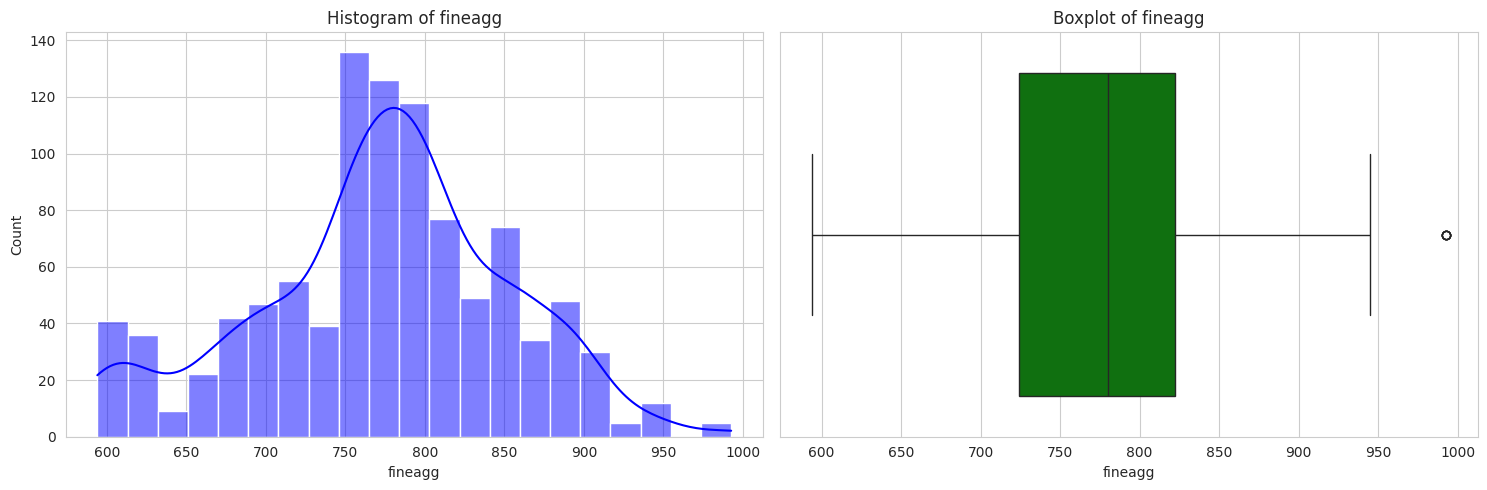

  Skewness: -0.25
  Kurtosis: -0.11


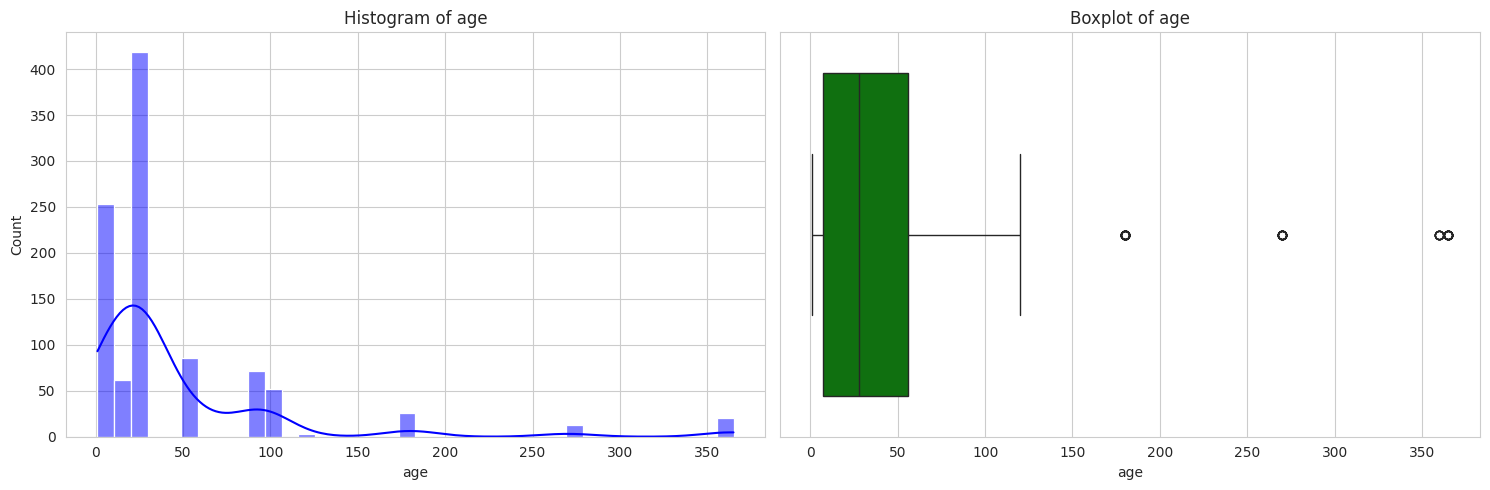

  Skewness: 3.25
  Kurtosis: 11.96


In [18]:
features = df.columns.tolist()[:-1]

for feature in features:
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))
    # Histogram
    sns.histplot(data = df, x = feature, ax= axes[0], kde= True, color= "blue")
    axes[0].set_title(f"Histogram of {feature}")
    axes[0].set_xlabel(f'{feature}')
    axes[0].set_ylabel('Count')

    # BoxPlot
    sns.boxplot(data = df, x = feature, ax= axes[1], color= "green")
    axes[1].set_title(f'Boxplot of {feature}')
    axes[1].set_xlabel(f'{feature}')

    plt.tight_layout()
    plt.show()

    print(f"  Skewness: {df[feature].skew():.2f}")
    print(f"  Kurtosis: {df[feature].kurt():.2f}")

- The feature distributions reveal notable variations in concrete mix compositions. Cement exhibits a roughly normal distribution with a slight positive skew, while slag, fly ash, and superplasticizer are highly right-skewed, indicating that these materials are either absent or used in small quantities in many mixes. Water, coarse aggregate, and fine aggregate show more continuous and relatively symmetric distributions, reflecting their fundamental role in concrete production. The age variable is heavily right-skewed, with most samples tested at early curing ages such as 7, 14, and 28 days. Overall, the distributions and observed outliers demonstrate the diversity of concrete formulations within the dataset.

#### Correlation and Heatmap

In [19]:
df.corr()['strength'].sort_values(ascending= False)[1:]

,strength
cement,0.488283
superplastic,0.344209
age,0.337367
slag,0.103374
ash,-0.080648
coarseagg,-0.144717
fineagg,-0.186448
water,-0.269624


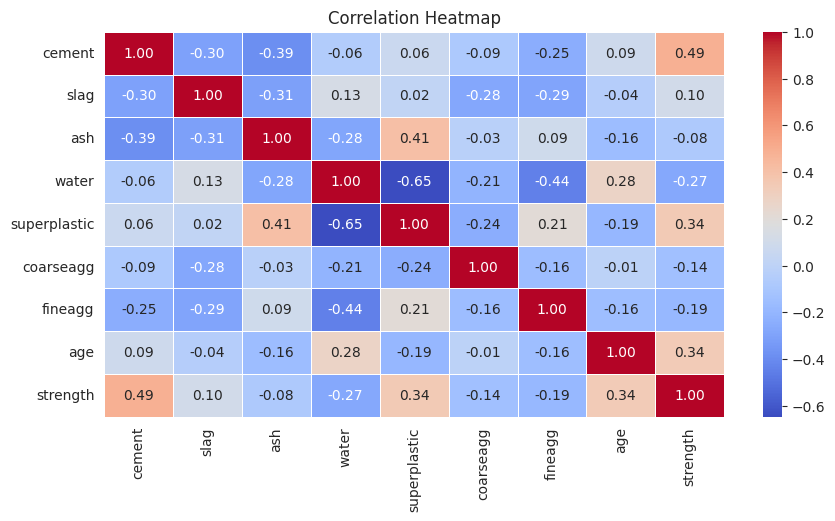

In [20]:
plt.figure(figsize= (10, 5))
sns.heatmap(df.corr(), annot= True, cmap= 'coolwarm', linewidths= 0.5, fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()

- The correlation analysis indicates that cement is the strongest positive predictor of compressive strength (r ≈ 0.49), followed by superplasticizer (r ≈ 0.34) and age (r ≈ 0.34). This suggests that higher cement content, increased use of superplasticizer, and longer curing periods generally contribute to greater concrete strength. Conversely, water exhibits a notable negative correlation (r ≈ -0.27), confirming the well-established influence of the water-cement ratio on strength development. Fine aggregate, coarse aggregate, fly ash, and slag show relatively weak correlations with compressive strength. Overall, the results highlight cement, superplasticizer, age, and water content as the most influential factors affecting concrete strength in the dataset.

#### Scatterplots

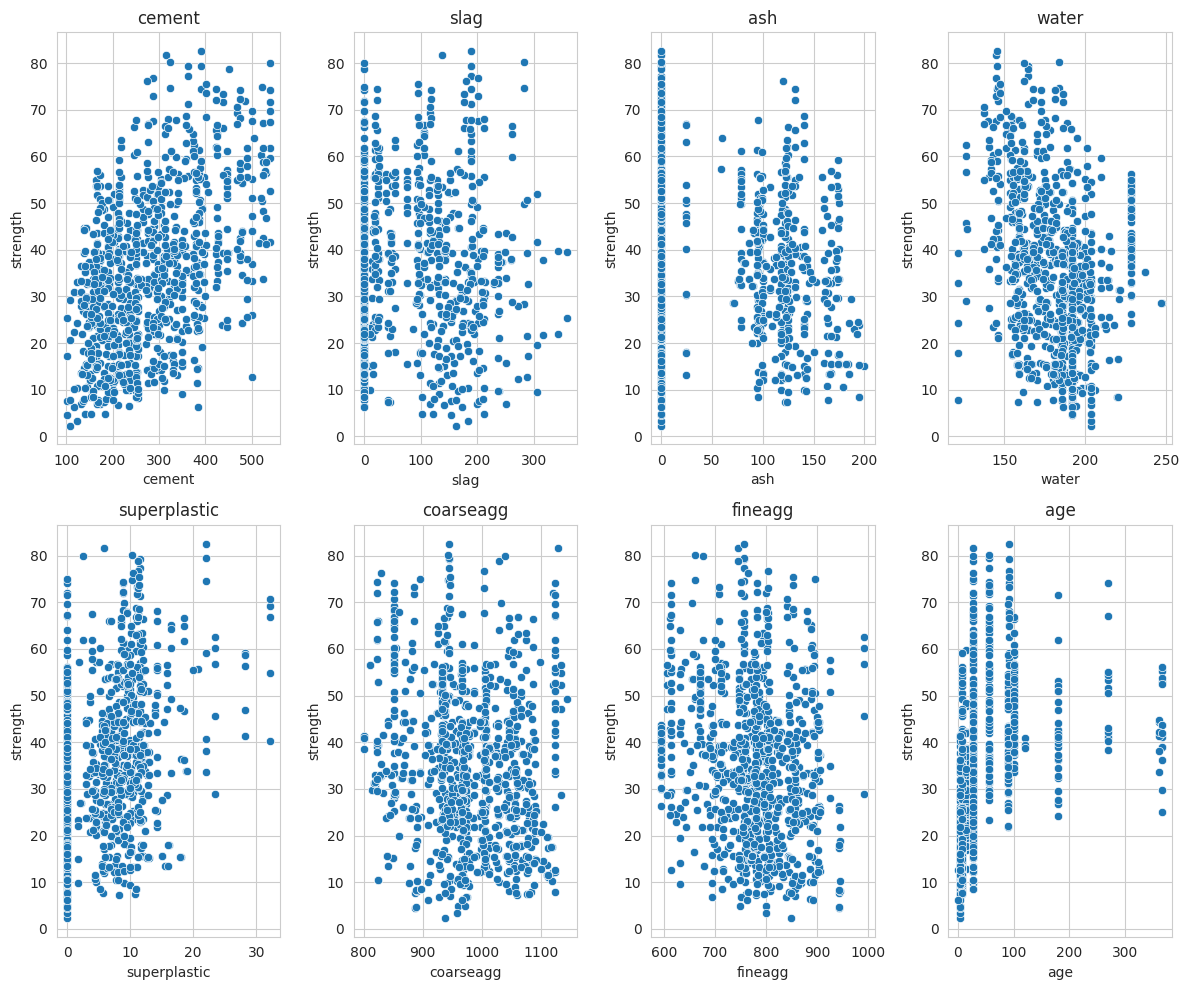

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(data = df, x = col, y = 'strength', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

- The scatter plots reveal that cement, superplasticizer, and age have clear positive relationships with compressive strength, indicating that higher values of these variables generally lead to stronger concrete. Age exhibits a nonlinear trend, with strength increasing rapidly at early curing stages before gradually leveling off. In contrast, water content shows a clear negative relationship with strength, confirming the adverse effect of higher water content on concrete performance. Slag, fly ash, coarse aggregate, and fine aggregate display weaker and less distinct relationships, suggesting that their individual influence on compressive strength is less pronounced. Overall, cement, water, superplasticizer, and age appear to be the most influential factors affecting concrete strength in the dataset.

### Feature Engineering

In [22]:
# Custom Transformer
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X, y = None):
        return self
    def transform(self, X):
        X = X.copy()
        X['water_cement_ratio'] = X['water'] / X['cement']
        X['binders'] = X['ash'] + X['slag'] + X['cement']
        X["water_binders_ratio"] = X['water'] / X['binders']
        X["total_aggregates"] = X['coarseagg'] + X['fineagg']
        X["total_aggregates_ratio"] = X['total_aggregates'] / X['cement']
        X["age"] = np.log1p(X["age"])
        return X

In [23]:
# Engineered features correlation with Strength
feature_engineering = FeatureEngineering()

df_fe = feature_engineering.transform(df)
df_fe.corr()['strength'].sort_values(ascending= False)[1:]

,strength
binders,0.598103
age,0.559853
cement,0.488283
superplastic,0.344209
slag,0.103374
ash,-0.080648
coarseagg,-0.144717
fineagg,-0.186448
total_aggregates,-0.256342
water,-0.269624


- Feature engineering significantly improved the relationships between the predictors and compressive strength. The newly created binders feature exhibited the strongest positive correlation with strength (r ≈ 0.60), outperforming cement alone and highlighting the collective importance of cementitious materials. Similarly, the log-transformed age variable showed a stronger positive relationship, indicating that the nonlinear effect of curing time was better captured after transformation.

- Among the engineered features, water_binders_ratio displayed the strongest negative correlation (r ≈ -0.61), making it the most influential inverse predictor of concrete strength. This finding aligns with concrete technology principles, where excess water relative to binder content reduces strength. The water_cement_ratio also showed a strong negative correlation (r ≈ -0.49), while total_aggregates_ratio exhibited a moderate negative relationship (r ≈ -0.47).

- Overall, the engineered features demonstrated stronger correlations with compressive strength than most original variables, suggesting that they capture key mix-design relationships and are likely to improve predictive model performance.

### Data Preparation

In [24]:
X = df.drop('strength', axis = 1)
y = df['strength']

X_train, X_test_full, y_train, y_test_full = train_test_split(X, y, test_size = 0.3, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_test_full, y_test_full, test_size = 0.5, random_state = 42)


In [25]:
# Model Pipeline
def model_pipeline(model):
    pipeline = Pipeline([
        ('feature_engineering', FeatureEngineering()),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    return pipeline

# Model Evaluation
def model_evaluation(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


### Baseline Model

In [26]:
linear_model = model_pipeline(LinearRegression())
linear_model.fit(X_train, y_train)
linear_model_pred = linear_model.predict(X_val)

In [27]:
linear_mae, linear_rmse, linear_r2 = model_evaluation(y_val, linear_model_pred)

In [28]:
print(f"Baseline Linear Regression Model Performance on Validation Set\n")
print(f"- Mean Absolute Error (MAE): {linear_mae:.2f}")
print(f"- Root Mean Squared Error (RMSE): {linear_rmse:.2f}")
print(f"- R-squared (R²): {linear_r2:.2f}")

Baseline Linear Regression Model Performance on Validation Set

- Mean Absolute Error (MAE): 5.84
- Root Mean Squared Error (RMSE): 7.95
- R-squared (R²): 0.76


### Non-Linear Model Training

In [29]:
models = {
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Support Vector Machine": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state= 42),
    "Random Forest": RandomForestRegressor(random_state= 42),
    "Gradient Boosting": GradientBoostingRegressor(random_state= 42),
    "XGBoost": XGBRegressor(random_state = 42)
}

model_performance = {}

for name, model in models.items():
    model = model_pipeline(model)
    model.fit(X_train, y_train)
    model_pred = model.predict(X_val)

    mae, rmse, r2 = model_evaluation(y_val, model_pred)

    model_performance[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

In [30]:
model_performance_df = pd.DataFrame(model_performance)
model_performance_df['Linear Regression'] = [linear_mae, linear_rmse, linear_r2]
model_performance_df = model_performance_df.T.sort_values(by = 'R2', ascending = False)

baseline_r2 = model_performance_df.loc["Linear Regression", "R2"]

model_performance_df["R2 Improvement (%)"] = (
    (model_performance_df["R2"] - baseline_r2)
    / baseline_r2
) * 100

display(model_performance_df)

,MAE,RMSE,R2,R2 Improvement (%)
Random Forest,3.268296,5.209175,0.895653,18.331826
XGBoost,3.034987,5.267847,0.893289,18.019522
Gradient Boosting,3.598612,5.450708,0.885752,17.023744
K-Nearest Neighbors,4.703258,6.424064,0.841305,11.151517
Decision Tree,4.642616,7.437030,0.787312,4.018087
Linear Regression,5.836292,7.950991,0.756899,0.000000
Support Vector Machine,5.715996,8.033673,0.751817,-0.671459


- The performance of six machine learning models was evaluated using MAE, RMSE, and R² on the validation dataset, with Linear Regression serving as the baseline model. The results show that ensemble-based methods significantly outperformed the baseline model. Random Forest achieved the best overall performance, recording the lowest RMSE (5.21 MPa) and the highest R² (0.896), indicating that it explained approximately 89.6% of the variance in compressive strength. XGBoost produced a comparable performance, achieving the lowest MAE (3.03 MPa) and an R² of 0.893. Gradient Boosting also demonstrated strong predictive capability, with an R² of 0.886.

- In contrast, K-Nearest Neighbors and Decision Tree models achieved moderate performance, while Linear Regression and Support Vector Machine yielded the weakest results, with R² values of 0.757 and 0.752 respectively. The superior performance of the ensemble models suggests that the relationship between concrete mix parameters and compressive strength is highly nonlinear, making tree-based ensemble methods more suitable than linear approaches.

- Compared with the baseline Linear Regression model, Random Forest and XGBoost improved the coefficient of determination (R²) by approximately 18%, demonstrating the ability of ensemble learning methods to better capture the nonlinear relationships between concrete mix constituents and compressive strength.

- Overall, Random Forest and XGBoost emerged as the most effective models for predicting concrete compressive strength, substantially improving prediction accuracy over the baseline Linear Regression model.

### Hyperparameter Tuning (Optuna)

#### XGBoost

In [46]:
def objective_xgboost(trial):
    # Define hyperparameter search space for XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0, step=0.1),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 1.0, log=True),
        'random_state': 42
    }

    # Create and train the model within the pipeline
    model = model_pipeline(XGBRegressor(**param))
    model.fit(X_train, y_train)

    # Make predictions and evaluate
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    return rmse

In [47]:
print('Starting Optuna study for XGBoost...')
xgb_study = optuna.create_study(direction='minimize', study_name= 'XGBoost Optimization')
xgb_study.optimize(objective_xgboost, n_trials=150)

print('\n XGBoost Best trial:')
print(f'  Value: {xgb_study.best_value:.4f} (RMSE)')
print('  Params: ')
for key, value in xgb_study.best_params.items():
    print(f'    {key}: {value}')

[I 2026-06-27 10:51:51,446] A new study created in memory with name: XGBoost Optimization


Starting Optuna study for XGBoost...


[I 2026-06-27 10:51:52,525] Trial 0 finished with value: 4.977844529716652 and parameters: {'n_estimators': 900, 'max_depth': 9, 'learning_rate': 0.03456097028099455, 'subsample': 0.9, 'colsample_bytree': 0.6, 'gamma': 0.05754520534737129, 'min_child_weight': 10, 'reg_alpha': 0.07011603276071304, 'reg_lambda': 0.011398435861050637}. Best is trial 0 with value: 4.977844529716652.
[I 2026-06-27 10:51:53,907] Trial 1 finished with value: 5.030047121680657 and parameters: {'n_estimators': 1500, 'max_depth': 10, 'learning_rate': 0.032194418077630925, 'subsample': 0.7, 'colsample_bytree': 0.6, 'gamma': 0.4483229363814766, 'min_child_weight': 8, 'reg_alpha': 0.0014340199344493902, 'reg_lambda': 0.010803531951490234}. Best is trial 0 with value: 4.977844529716652.
[I 2026-06-27 10:51:54,254] Trial 2 finished with value: 4.958535559671161 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2455586218647665, 'subsample': 0.7, 'colsample_bytree': 0.6, 'gamma': 0.1252688633601


 XGBoost Best trial:
  Value: 4.6213 (RMSE)
  Params: 
    n_estimators: 1300
    max_depth: 8
    learning_rate: 0.06053684395941341
    subsample: 0.7
    colsample_bytree: 0.8
    gamma: 0.13796683693193976
    min_child_weight: 1
    reg_alpha: 0.0251360139833716
    reg_lambda: 0.2020134593188318


#### Random Forest

In [51]:
def objective_random_forest(trial):
    # Define hyperparameter search space for Random Forest
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.6, 1.0, step=0.1),
        'random_state': 42
    }

    # Create and train the model within the pipeline
    model = model_pipeline(RandomForestRegressor(**param))
    model.fit(X_train, y_train)

    # Make predictions and evaluate
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    return rmse

In [52]:
print('Starting Optuna study for Random Forest...')
rf_study = optuna.create_study(direction='minimize', study_name= 'Random Forest Optimization')
rf_study.optimize(objective_random_forest, n_trials=100)

print('\n Random Forest Best trial:')
print(f'  Value: {rf_study.best_value:.4f} (RMSE)')
print('  Params: ')
for key, value in rf_study.best_params.items():
    print(f'    {key}: {value}')


[I 2026-06-27 11:01:41,601] A new study created in memory with name: Random Forest Optimization


Starting Optuna study for Random Forest...


[I 2026-06-27 11:01:45,992] Trial 0 finished with value: 5.499693103121202 and parameters: {'n_estimators': 900, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 1.0}. Best is trial 0 with value: 5.499693103121202.
[I 2026-06-27 11:01:46,719] Trial 1 finished with value: 5.796688220220571 and parameters: {'n_estimators': 100, 'max_depth': 22, 'min_samples_split': 19, 'min_samples_leaf': 5, 'max_features': 1.0}. Best is trial 0 with value: 5.499693103121202.
[I 2026-06-27 11:01:47,380] Trial 2 finished with value: 6.176287106534494 and parameters: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 0.8}. Best is trial 0 with value: 5.499693103121202.
[I 2026-06-27 11:01:50,097] Trial 3 finished with value: 5.637472633611883 and parameters: {'n_estimators': 500, 'max_depth': 24, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 0.7}. Best is trial 0 with value: 5.499693103121202.
[I 2026-06-27 11


 Random Forest Best trial:
  Value: 5.1126 (RMSE)
  Params: 
    n_estimators: 200
    max_depth: 22
    min_samples_split: 2
    min_samples_leaf: 1
    max_features: 0.6


In [53]:
# Result Table
result = {
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE Before': [model_performance_df.loc['Random Forest', 'RMSE'], model_performance_df.loc['XGBoost', 'RMSE']],
    'RMSE After': [rf_study.best_value, xgb_study.best_value],
}
result_df = pd.DataFrame(result)
result_df['Improvement (%)'] = (result_df['RMSE Before'] - result_df['RMSE After']) / result_df['RMSE Before'] * 100
result_df.round(3)

,Model,RMSE Before,RMSE After,Improvement (%)
0,Random Forest,5.209,5.113,1.854
1,XGBoost,5.268,4.621,12.273


- Hyperparameter optimization was performed using Optuna to improve the predictive performance of the two best-performing models identified during initial evaluation. The tuned Random Forest model achieved an RMSE of 5.113 MPa, representing a modest improvement over the default configuration. In contrast, the tuned XGBoost model achieved an RMSE of 4.621 MPa, substantially outperforming both the default XGBoost model and the tuned Random Forest model.

- The results indicate that XGBoost was better able to exploit the nonlinear relationships within the dataset when appropriately tuned. Consequently, the tuned XGBoost model was selected as the final model for concrete compressive strength prediction due to its superior predictive accuracy.

### Final Model

In [54]:
best_params = xgb_study.best_params
best_params['random_state'] = 42

final_model = model_pipeline(XGBRegressor(**best_params))

X_train_full = pd.concat([X_train, X_val], axis = 0)
y_train_full = pd.concat([y_train, y_val], axis = 0)

final_model.fit(X_train_full, y_train_full)

final_model_pred = final_model.predict(X_test)

final_mae, final_rmse, final_r2 = model_evaluation(y_test, final_model_pred)

In [57]:
print(f"Final Model Performance on Test Set\n")
print(f"- Mean Absolute Error (MAE): {final_mae:.2f}")
print(f"- Root Mean Squared Error (RMSE): {final_rmse:.2f}")
print(f"- R-squared (R²): {final_r2:.2f}")

Final Model Performance on Test Set

- Mean Absolute Error (MAE): 2.38
- Root Mean Squared Error (RMSE): 3.63
- R-squared (R²): 0.95


- The final tuned XGBoost model achieved a Mean Absolute Error (MAE) of 2.38 MPa, a Root Mean Squared Error (RMSE) of 3.63 MPa, and an R² score of 0.95 on the unseen test set. These results indicate that the model can predict concrete compressive strength with high accuracy, explaining approximately 95% of the variability in the target variable. The low MAE and RMSE values suggest that prediction errors are relatively small compared to the overall strength range of the dataset, demonstrating strong generalization performance on unseen data.

### Residual Plot

In [58]:
residuals = y_test - final_model_pred

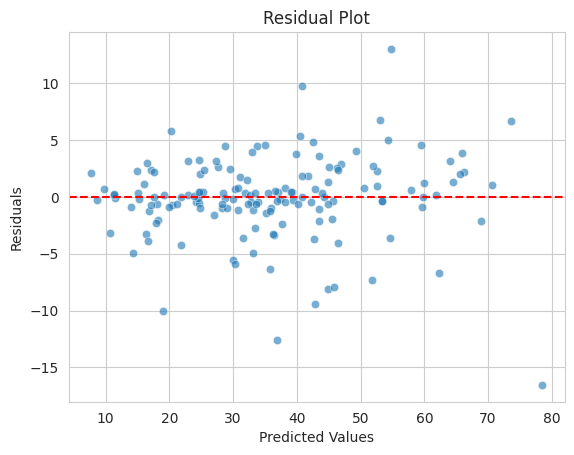

In [59]:
sns.scatterplot(x = final_model_pred, y = residuals, alpha = 0.6)
plt.axhline(y = 0, color = 'r', linestyle = '--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

- The residual plot shows that the prediction errors are randomly distributed around zero, with no obvious systematic pattern. This indicates that the model has successfully captured the underlying relationship between the input variables and concrete compressive strength. Most residuals are relatively small and centered near zero, suggesting that the model's predictions are generally unbiased. Although a few observations exhibit larger positive or negative residuals, these appear to be isolated cases rather than evidence of a broader modeling issue. Overall, the residual analysis supports the strong predictive performance indicated by the high R² (0.95) and low error metrics.

### Actual vs Predicted Plot

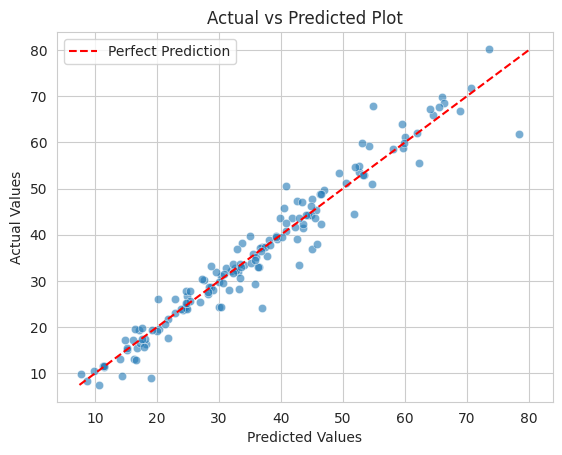

In [60]:
sns.scatterplot(x = final_model_pred, y = y_test, alpha = 0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label = 'Perfect Prediction')
plt.legend()
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Actual vs Predicted Plot')
plt.show()

- The Actual vs Predicted plot shows a strong agreement between the observed and predicted compressive strength values. Most data points lie close to the 45-degree reference line representing perfect predictions, indicating that the model is able to accurately estimate concrete compressive strength across a wide range of values. Only a few observations deviate noticeably from the reference line, suggesting that large prediction errors are rare. Overall, the close clustering of points around the ideal prediction line confirms the high predictive accuracy of the tuned XGBoost model.

### Error Analysis for High Residuals

In [61]:
error_analysis_df = X_test.copy()
error_analysis_df['Actual_Strength'] = y_test.values
error_analysis_df['Predicted_Strength'] = final_model_pred
error_analysis_df['Residuals'] = residuals.values

# Sort by absolute residuals to find the largest errors
highest_residuals = error_analysis_df.reindex(error_analysis_df['Residuals'].abs().sort_values(ascending=False).index)

print("Top 10 instances with the highest absolute residuals:")
display(highest_residuals.head(10))

Top 10 instances with the highest absolute residuals:


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,Actual_Strength,Predicted_Strength,Residuals
101,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,78.445503,-16.555503
834,337.9,189.0,0.0,174.9,9.5,944.7,755.8,91,67.80,54.754719,13.045281
432,168.0,42.1,163.8,121.8,5.7,1058.7,780.1,28,24.24,36.870071,-12.630071
382,349.0,0.0,0.0,192.0,0.0,1056.0,809.0,7,9.01,19.052832,-10.042832
752,252.3,0.0,98.8,146.3,14.2,987.8,889.0,28,50.60,40.806297,9.793703
490,491.0,26.0,123.0,210.0,3.9,882.0,699.0,7,33.49,42.876423,-9.386423
663,387.0,20.0,94.0,157.0,14.3,938.0,845.0,7,36.84,44.935493,-8.095493
300,491.0,26.0,123.0,201.0,3.9,822.0,699.0,7,37.92,45.859917,-7.939917
33,313.0,145.0,0.0,127.0,8.0,1000.0,822.0,28,44.52,51.818356,-7.298356
208,337.9,189.0,0.0,174.9,9.5,944.7,755.8,56,59.89,53.084129,6.805871


- Error analysis showed that the largest prediction errors occurred primarily for concrete mixtures with extreme mix proportions or atypical curing ages. In particular, several high-error samples contained unusually high cement contents or were tested at very early curing ages (7 days), where concrete strength develops rapidly and exhibits highly nonlinear behavior. Despite these isolated cases, the majority of predictions closely matched the experimental values, as evidenced by the low MAE (2.38 MPa), low RMSE (3.63 MPa), and high coefficient of determination (R² = 0.95). This demonstrates that the tuned XGBoost model generalizes well across a wide range of concrete mixtures while maintaining robust predictive performance.

### SHAP Analysis (Global and Local Interpretability)

In [62]:
# Extract the feature engineering and scaler steps from the final pipeline
feature_engineer_step = final_model.named_steps['feature_engineering']
scaler_step = final_model.named_steps['scaler']
xgboost_model_step = final_model.named_steps['model']

# Apply feature engineering and scaling to X_test
X_test_fe = feature_engineer_step.transform(X_test)
X_test_scaled = scaler_step.transform(X_test_fe)

# Get feature names after engineering
original_features = X_test.columns.tolist()
engineered_features = ['water_cement_ratio', 'binders', 'water_binders_ratio', 'total_aggregates', 'total_aggregates_ratio']
all_features = original_features + engineered_features

# Create a DataFrame for X_test_scaled with correct column names for SHAP
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=all_features, index=X_test.index)

# Initialize SHAP explainer for tree-based models
explainer = shap.TreeExplainer(xgboost_model_step)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled_df)

print("SHAP values calculated.")

SHAP values calculated.


#### Global Interpretability: SHAP Summary Plot

The SHAP summary plot provides an overview of the importance of each feature and its impact on the model's output. Each point on the plot represents a single prediction for a single feature value. The horizontal location shows the SHAP value, indicating the impact of that feature value on the prediction. The color indicates the feature value (red for high, blue for low), and the vertical position indicates the feature. Features are ordered by their overall importance.

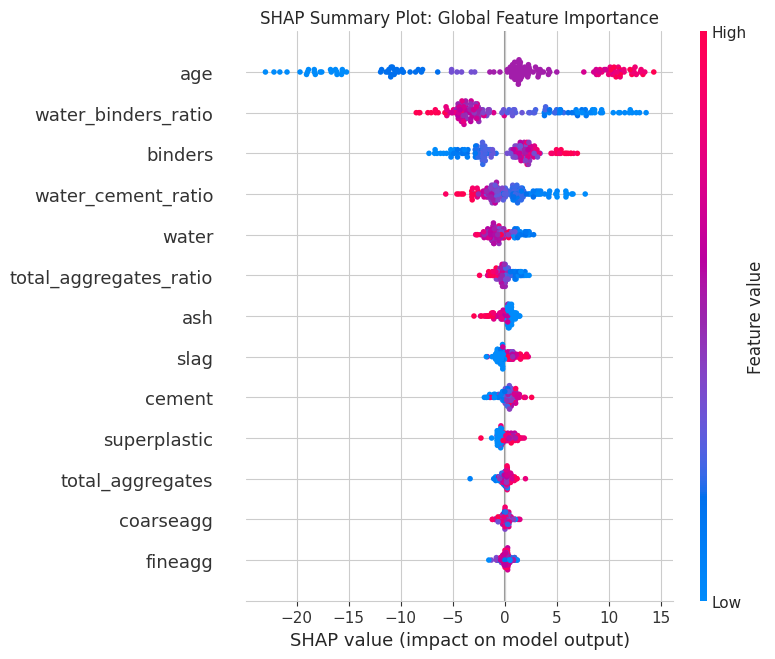

In [63]:
# Create the SHAP summary plot
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.title('SHAP Summary Plot: Global Feature Importance')
plt.tight_layout()
plt.show()

#### SHAP Feature Importance (Bar Plot)

The SHAP bar plot displays the mean absolute SHAP value for each feature, providing a concise global view of feature importance. Features with larger mean absolute SHAP values have a greater average impact on the model's predictions.

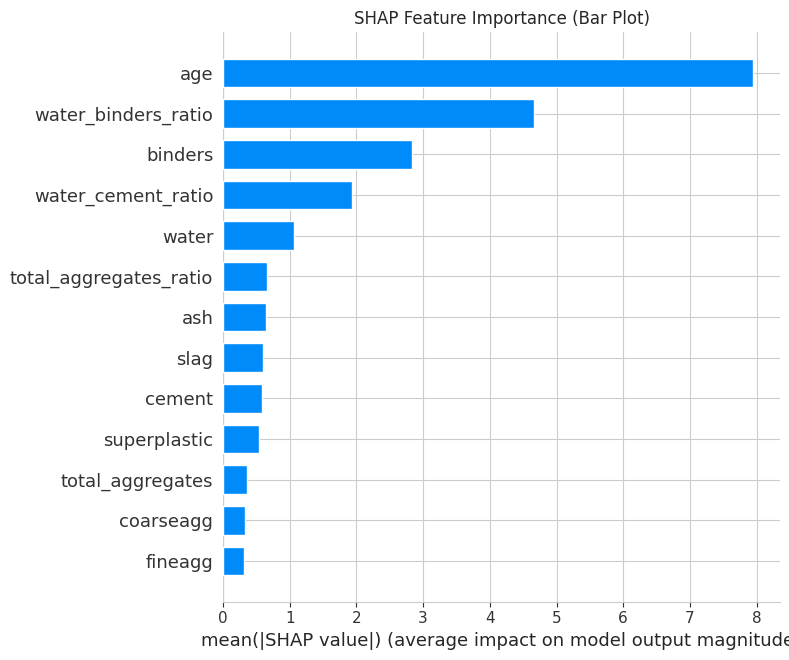

In [64]:
# Create the SHAP bar plot for global feature importance
fig = shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar Plot)')
plt.tight_layout()
plt.show()

#### SHAP Waterfall Plot for a specific instance

The SHAP waterfall plot provides a detailed breakdown of a single prediction, showing how each feature contributes to pushing the model's output from the `expected_value` (base value) to the `output_value` (prediction for that instance). Each bar represents the contribution of a feature, and the sum of these contributions, plus the base value, equals the final prediction.

Explaining prediction for instance 0 (Actual Strength: 49.77, Predicted Strength: 46.89)


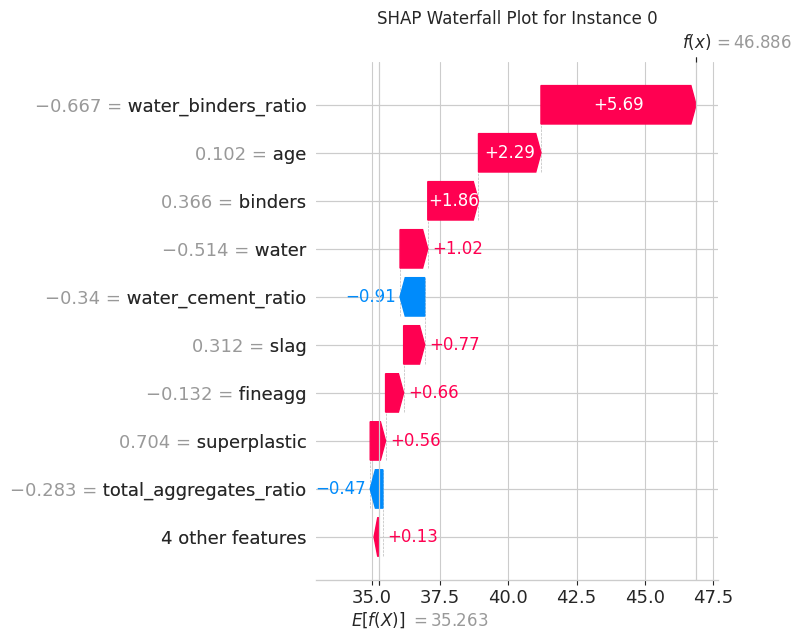

In [65]:
# Select an instance to explain (e.g., the first instance in the test set)
instance_index = 0
sample_instance_values = shap_values[instance_index, :]

# Create a SHAP Explanation object for the waterfall plot
shap_explanation = shap.Explanation(values=sample_instance_values,
                                   base_values=explainer.expected_value,
                                   data=X_test_scaled_df.iloc[instance_index],
                                   feature_names=X_test_scaled_df.columns.tolist())

# Generate a waterfall plot for this instance
print(f"Explaining prediction for instance {instance_index} (Actual Strength: {y_test.iloc[instance_index]:.2f}, Predicted Strength: {final_model_pred[instance_index]:.2f})")
shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'SHAP Waterfall Plot for Instance {instance_index}')
plt.tight_layout()
plt.show()

- SHAP analysis revealed that curing age was the most influential predictor of concrete compressive strength, followed by water-binder ratio and binder content. Higher curing ages and greater binder contents increased the predicted strength, whereas higher water-binder and water-cement ratios reduced it. These findings are consistent with established principles of concrete technology, where prolonged curing enhances hydration and lower water-to-binder ratios produce denser, stronger concrete. Furthermore, the engineered features exhibited greater importance than most of the original variables, indicating that engineering-informed feature engineering significantly improved the model's ability to capture the underlying relationships governing concrete strength.

### Model Saving

In [66]:
import joblib

# Define the path where the model will be saved in Google Drive
model_save_path = '/content/drive/MyDrive/concrete_strength_model.joblib'

# Save the final_model pipeline
joblib.dump(final_model, model_save_path)

print(f"Model successfully saved to: {model_save_path}")

Model successfully saved to: /content/drive/MyDrive/concrete_strength_model.joblib
